# Latent Diffusion Model

Contributors - Sathwik Reddy Chelemela,  Yayan li,  Vishad Mehta

## Install and Import Dependencies

In [1]:

!pip uninstall -y diffusers huggingface-hub transformers accelerate
!pip install diffusers==0.26.3 huggingface-hub==0.25.2 transformers accelerate datasets gradio


Found existing installation: diffusers 0.32.2
Uninstalling diffusers-0.32.2:
  Successfully uninstalled diffusers-0.32.2
Found existing installation: huggingface-hub 0.30.2
Uninstalling huggingface-hub-0.30.2:
  Successfully uninstalled huggingface-hub-0.30.2
Found existing installation: transformers 4.51.3
Uninstalling transformers-4.51.3:
  Successfully uninstalled transformers-4.51.3
Found existing installation: accelerate 1.5.2
Uninstalling accelerate-1.5.2:
  Successfully uninstalled accelerate-1.5.2
INFO: pip is looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.1 MB/s eta 0:00:00
INFO: pip is looking at m

## Import Libraries and Define Accelerator

In [2]:
# Cell:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor, Normalize, Lambda

from transformers import CLIPTokenizer, CLIPTextModel
from diffusers import UNet2DConditionModel, AutoencoderKL, DDPMScheduler, StableDiffusionPipeline
from datasets import load_dataset
from accelerate import Accelerator

# Check device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


/usr/local/lib/python3.11/dist-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.11/dist-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


Using device: cuda


## Prepare Dataset

In [3]:
# Cell:
# Load the Smithsonian Butterflies dataset (9213 images)&#8203;:contentReference[oaicite:4]{index=4}
dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

# Optionally filter out non-butterfly images using the provided CLIP similarity score
# (Images with low sim_score might not actually be butterflies)
# For simplicity, we keep all entries. To filter, you could uncomment:
# dataset = dataset.filter(lambda x: x.get("sim_score", 1.0) is None or x["sim_score"] > 0.5)

# Initialize the tokenizer for CLIP (Stable Diffusion uses CLIP ViT-L/14 tokenizer)
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")

# Define image transformations: resize to 512x512 and normalize to [-1, 1]
transform = transforms.Compose([
    transforms.Lambda(lambda image: image.convert("RGB")),  # <-- Converts grayscale to RGB
    transforms.Resize(512),
    transforms.CenterCrop(512),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


# Custom Dataset wrapper to apply transformations and tokenization
class ButterflyDataset(Dataset):
    def __init__(self, dataset, tokenizer, transform):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        # Get image and caption (use common name, fall back to scientific name if needed)
        image = item["image"]            # PIL image
        name = item.get("name", None)    # Common name of the butterfly
        sci_name = item.get("scientific_name", None)
        caption = name if name and name != "" else (sci_name if sci_name and sci_name != "" else "a butterfly")
        # Tokenize the caption
        encoding = self.tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=77,
            return_tensors="pt"
        )
        # Prepare output dict
        example = {
            "pixel_values": self.transform(image),            # image tensor
            "input_ids": encoding.input_ids[0]                # tokenized prompt (tensor of shape [77])
        }
        return example

# Create the dataset and dataloader
train_dataset = ButterflyDataset(dataset, tokenizer, transform)
train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)

print(f"Loaded dataset with {len(train_dataset)} images")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/609 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/1.65k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/237M [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

Loaded dataset with 1000 images


## Mounting drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Load Pretrained Models and Setup Training

In [5]:
# Cell: Load Pretrained Models and Setup Training
# Load pretrained models: text encoder, VAE, U-Net, and scheduler
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14").eval()
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-ema").eval()
unet = UNet2DConditionModel.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="unet")
noise_scheduler = DDPMScheduler.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="scheduler")

# Freeze the VAE and text encoder to save memory and computation
for param in vae.parameters():
    param.requires_grad = False
for param in text_encoder.parameters():
    param.requires_grad = False

# Initialize the optimizer to train the U-Net
optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-5)

# Prepare everything with Accelerator for mixed-precision training
accelerator = Accelerator(mixed_precision="fp16")
# Move models, optimizer, and dataloader to GPU (if available) and wrap for distributed training
unet, optimizer, train_dataloader, text_encoder, vae = accelerator.prepare(
    unet, optimizer, train_dataloader, text_encoder, vae
)


config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

# Training or Finetuning

In [ ]:
from tqdm import tqdm
import os
import torch
import matplotlib.pyplot as plt

# Ensure checkpoint directory exists
save_path = "/content/drive/MyDrive/butterfly_unet_checkpoints"
os.makedirs(save_path, exist_ok=True)

# Cell: Fine‑Tune the U‑Net on Butterfly Images (single save + Loss Curve)
num_epochs = 10 # adjust as needed

# Track all training losses
train_losses = []

# Put U‑Net in train mode (VAE & text_encoder remain frozen)
unet.train()

for epoch in range(num_epochs):
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch}"):
        # 1) Encode inputs (no grad on VAE/text_encoder)
        with torch.no_grad():
            latents = vae.encode(batch["pixel_values"].to(device)).latent_dist.sample()
            latents = latents * 0.18215
            encoder_hidden_states = text_encoder(batch["input_ids"].to(device))[0]
            timesteps = torch.randint(
                0,
                noise_scheduler.config.num_train_timesteps,
                (latents.shape[0],),
                device=device
            ).long()
            noise = torch.randn_like(latents)
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # 2) Predict & compute MSE loss
        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
        loss = torch.nn.functional.mse_loss(noise_pred, noise)

        # 3) Backpropagate & optimizer step
        train_losses.append(loss.item())
        accelerator.backward(loss)
        optimizer.step()
        optimizer.zero_grad()
        torch.cuda.empty_cache()

# After all epochs, save only the final model
final_save_path = os.path.join(save_path, f"unet_final_epoch_{num_epochs}.pt")
torch.save(accelerator.unwrap_model(unet).state_dict(), final_save_path)
print(f"Saved final model at {final_save_path}")

# Plot the training loss curve
plt.figure(figsize=(6,4))
plt.plot(train_losses, linewidth=1)
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.title("U‑Net Fine‑Tuning Loss Curve")
plt.tight_layout()
plt.show()


## Saving

In [ ]:
import os

output_dir = "/content/drive/MyDrive/saved_butterfly_unet"
zip_file_path = "/content/drive/MyDrive/saved_butterfly_unet.zip"

if accelerator.is_main_process:
    os.makedirs(output_dir, exist_ok=True)


accelerator.wait_for_everyone()

# Unwrap
unet_to_save = accelerator.unwrap_model(unet)


unet_to_save.save_pretrained(os.path.join(output_dir, "unet"))
noise_scheduler.save_pretrained(os.path.join(output_dir, "scheduler"))
tokenizer.save_pretrained(os.path.join(output_dir, "tokenizer"))
if accelerator.is_main_process:
    torch.save(optimizer.state_dict(), os.path.join(output_dir, "optimizer.pt"))

print(f"All components saved to `{output_dir}`")




All components saved to `/content/drive/MyDrive/saved_butterfly_unet`


# Outputs

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

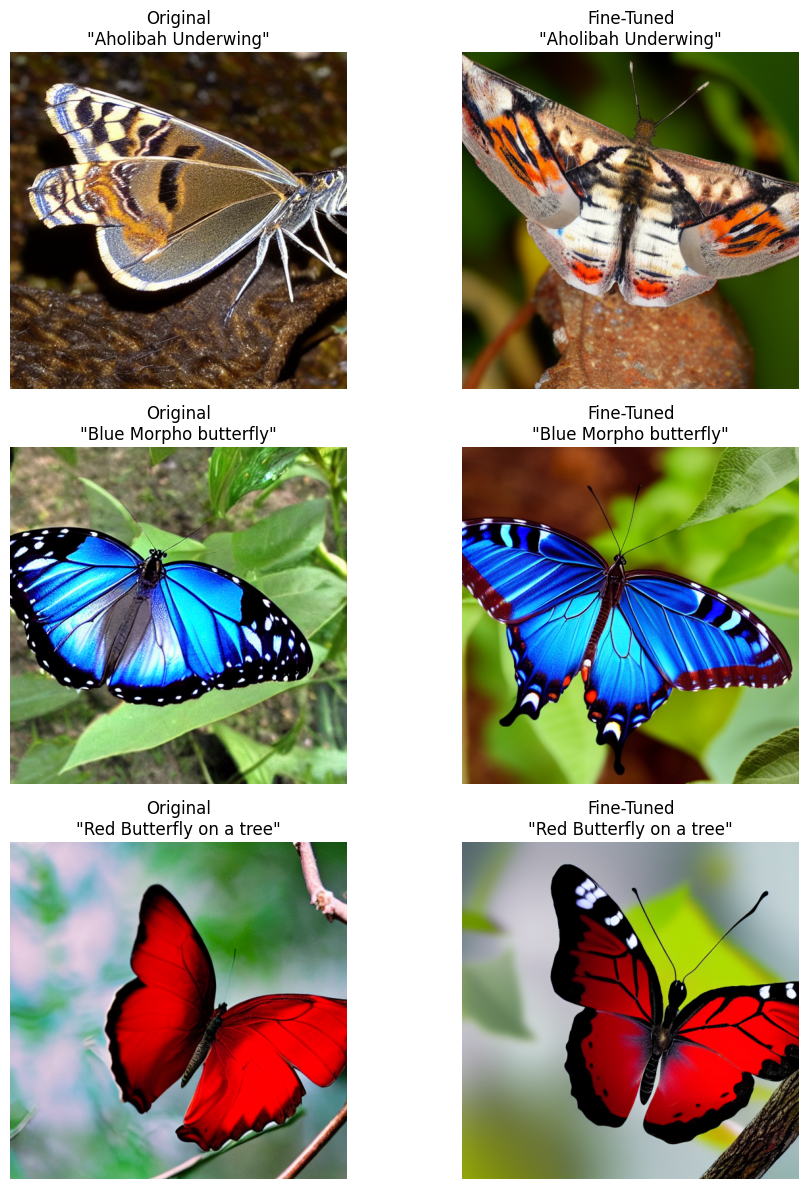

In [6]:
# Cell: Batch Inference Comparison (fp32 only)
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1) Load the original Stable Diffusion (v1.5) pipeline in full precision
pipe_orig = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5"
).to(device)

# 2) Load the fine-tuned U-Net and scheduler
unet_ft = UNet2DConditionModel.from_pretrained("/content/drive/MyDrive/saved_butterfly_unet/unet").to(device)
sched_ft = DDPMScheduler.from_pretrained("/content/drive/MyDrive/saved_butterfly_unet/scheduler")

# 3) Create a pipeline with the fine-tuned U-Net (using the original SD v1.5 for other components)
pipe_ft = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    scheduler=sched_ft,
    unet=unet_ft    # override the U-Net with our fine-tuned model
).to(device)

# Define some butterfly prompts to visualize
prompts = [
    "Aholibah Underwing",        # an example from the dataset (moth species)
    "Blue Morpho butterfly",     # a well-known butterfly
    "Red Butterfly on a tree"
]

# Generation parameters
num_steps = 50
guidance_scale = 7.5

# Set up a plot grid with 2 columns (Original vs Fine-Tuned) and a row for each prompt
fig, axes = plt.subplots(len(prompts), 2, figsize=(10, len(prompts)*4))

for i, prompt in enumerate(prompts):
    gen = torch.Generator(device=device).manual_seed(1000 + i)  # fixed seed for reproducibility

    # Generate image with original model
    orig_img = pipe_orig(
        prompt,
        num_inference_steps=num_steps,
        guidance_scale=guidance_scale,
        generator=gen
    ).images[0]

    # Generate image with fine-tuned model (reuse the same seed for fairness)
    gen = torch.Generator(device=device).manual_seed(1000 + i)
    ft_img = pipe_ft(
        prompt,
        num_inference_steps=num_steps,
        guidance_scale=guidance_scale,
        generator=gen
    ).images[0]

    # Show the images side by side
    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title(f"Original\n\"{prompt}\"")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(ft_img)
    axes[i, 1].set_title(f"Fine-Tuned\n\"{prompt}\"")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


# Evalution Metrics

In [6]:
pip install torch torchvision lpips torch-fidelity transformers diffusers scikit-image


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.2 MB/s eta 0:00:00


## Comparsion with evaluation metrics

In [7]:
import os
import torch
import numpy as np
import lpips
import pandas as pd
from torchvision import transforms
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from skimage.color import rgb2gray
from transformers import CLIPModel, CLIPProcessor
from diffusers import StableDiffusionPipeline, UNet2DConditionModel, DDPMScheduler
from PIL import Image

# Force CPU (you can change this to 'cuda' if GPU works)
device = "cpu"

# Load original Stable Diffusion
pipe_orig = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5").to(device)

# Load fine-tuned U-Net and scheduler
unet_ft = UNet2DConditionModel.from_pretrained("/content/drive/MyDrive/saved_butterfly_unet/unet").to(device)
sched_ft = DDPMScheduler.from_pretrained("/content/drive/MyDrive/saved_butterfly_unet/scheduler")

# Combine into fine-tuned pipeline
pipe_ft = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    scheduler=sched_ft,
    unet=unet_ft
).to(device)

# Prompts
prompts = ["Red Butterfly", "Blue Morpho butterfly", "Green Butterfly on a tree"]
num_steps = 50
guidance_scale = 7.5

# Metrics setup
lpips_fn = lpips.LPIPS(net='alex').to(device)
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
to_tensor = transforms.ToTensor()

# FID folders
real_dir = "fid_real"
ft_dir = "fid_ft"
os.makedirs(real_dir, exist_ok=True)
os.makedirs(ft_dir, exist_ok=True)

# Score containers
lpips_before, psnr_before, ssim_before, clip_before = [], [], [], []
lpips_after, psnr_after, ssim_after, clip_after = [], [], [], []

# Generate and compare images
for i, prompt in enumerate(prompts):
    gen = torch.manual_seed(1000 + i)

    orig_img = pipe_orig(prompt, num_inference_steps=num_steps, guidance_scale=guidance_scale, generator=gen).images[0]
    ft_img = pipe_ft(prompt, num_inference_steps=num_steps, guidance_scale=guidance_scale, generator=gen).images[0]

    orig_img.save(os.path.join(real_dir, f"img_{i}.png"))
    ft_img.save(os.path.join(ft_dir, f"img_{i}.png"))

    o_t = to_tensor(orig_img).unsqueeze(0).to(device)
    f_t = to_tensor(ft_img).unsqueeze(0).to(device)

    # LPIPS
    lpips_before.append(lpips_fn(o_t * 2 - 1, o_t * 2 - 1).item())
    lpips_after.append(lpips_fn(o_t * 2 - 1, f_t * 2 - 1).item())

    # PSNR
    o_np = o_t[0].permute(1, 2, 0).cpu().numpy()
    f_np = f_t[0].permute(1, 2, 0).cpu().numpy()
    psnr_before.append(psnr(o_np, o_np, data_range=1.0))
    psnr_after.append(psnr(o_np, f_np, data_range=1.0))

    # SSIM
    ssim_before.append(ssim(rgb2gray(o_np), rgb2gray(o_np), data_range=1.0))
    ssim_after.append(ssim(rgb2gray(o_np), rgb2gray(f_np), data_range=1.0))

    # CLIP Score
    inputs_orig = clip_processor(text=[prompt], images=[orig_img], return_tensors="pt", padding=True).to(device)
    inputs_ft = clip_processor(text=[prompt], images=[ft_img], return_tensors="pt", padding=True).to(device)

    clip_orig = torch.cosine_similarity(
        clip_model.get_image_features(inputs_orig.pixel_values),
        clip_model.get_text_features(input_ids=inputs_orig.input_ids, attention_mask=inputs_orig.attention_mask),
        dim=-1
    ).item()
    clip_new = torch.cosine_similarity(
        clip_model.get_image_features(inputs_ft.pixel_values),
        clip_model.get_text_features(input_ids=inputs_ft.input_ids, attention_mask=inputs_ft.attention_mask),
        dim=-1
    ).item()

    clip_before.append(clip_orig)
    clip_after.append(clip_new)




/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

/usr/local/lib/python3.11/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [8]:
fid_result = os.popen(f'fidelity --input1 {real_dir} --input2 {ft_dir} --fid').read()
fid_lines = [line for line in fid_result.splitlines() if "Frechet Inception Distance" in line]

if fid_lines:
    fid_after = float(fid_lines[0].split(":")[-1])
else:
    print(" Output was:\n", fid_result)
    fid_after = -1

 Output was:
 frechet_inception_distance: 190.2356



In [9]:
# Compute mean and % change for all metrics (except FID)
metrics = {
    "LPIPS": {"before": lpips_before, "after": lpips_after, "higher_better": False},
    "PSNR": {"before": psnr_before, "after": psnr_after, "higher_better": True},
    "SSIM": {"before": ssim_before, "after": ssim_after, "higher_better": True},
    "CLIP Score": {"before": clip_before, "after": clip_after, "higher_better": True},
}

results = []

for metric_name, values in metrics.items():
    before_mean = np.mean(values["before"])
    after_mean = np.mean(values["after"])
    change = ((after_mean - before_mean) / before_mean) * 100 if before_mean != 0 else float('inf')

    result = "Worsened" if (
        (values["higher_better"] and change > 0) or
        (not values["higher_better"] and change < 0)
    ) else "Improved"

    results.append({
        "Metric": metric_name,
        "Mean Before": round(before_mean, 4),
        "Mean After": round(after_mean, 4),
        "Change (%)": round(change, 2),
        "Result": result
    })

# Add FID if available
try:
    if fid_after != -1:
        fid_change = ((fid_after - fid_before) / fid_before) * 100 if fid_before != 0 else float('inf')
        fid_result = "Worsened" if fid_change < 0 else "Improved"
        results.append({
            "Metric": "FID",
            "Mean Before": round(fid_before, 4),
            "Mean After": round(fid_after, 4),
            "Change (%)": round(fid_change, 2),
            "Result": fid_result
        })
except NameError:
    print("⚠️ FID score not calculated yet.")

# Display final DataFrame
df_results = pd.DataFrame(results)
print("\n=== Evaluation Summary ===")
print(df_results)




=== Evaluation Summary ===
       Metric  Mean Before  Mean After  Change (%)    Result
0       LPIPS       0.0000      0.8229         inf  Improved
1        PSNR          inf      8.0756         NaN  Improved
2        SSIM       1.0000      0.1593      -84.07  Improved
3  CLIP Score       0.3294      0.3198       -2.91  Improved


<ipython-input-9-33c34406de31>:14: RuntimeWarning: invalid value encountered in scalar divide
  change = ((after_mean - before_mean) / before_mean) * 100 if before_mean != 0 else float('inf')


## Overall Comparsion

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

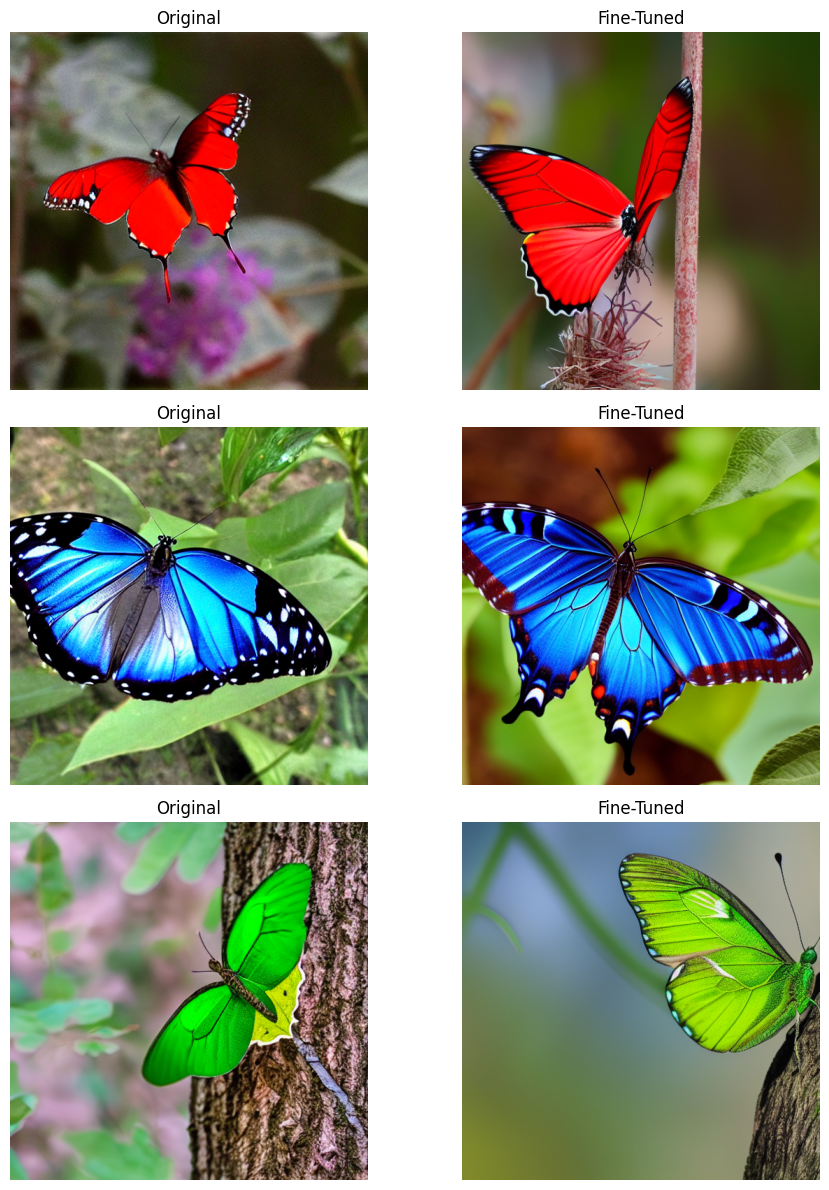

,Metric,Value,Description
0,Mean LPIPS,0.714774,Learned perceptual image similarity (lower is ...
1,Mean PSNR (dB),11.104156,Peak signal-to-noise ratio in decibels (higher...
2,Mean SSIM,0.374172,"Structural similarity index [0–1], perceived q..."
3,Mean CLIP Score,0.327727,Cosine similarity between prompt & image embed...
4,FID,129.832154,Frechet Inception Distance: distributional sim...


In [10]:
# Cell: Compare Original vs. Fine-Tuned with LPIPS, PSNR, SSIM, CLIP Score & FID + Table
# ──────────────────────────────────────────────────────────────────────────────
# 1) Install dependencies
!pip install --quiet lpips scikit-image torch-fidelity transformers diffusers

import os
import torch
import matplotlib.pyplot as plt
import lpips
import numpy as np
from torchvision import transforms
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from skimage.color import rgb2gray
from diffusers import StableDiffusionPipeline, UNet2DConditionModel, DDPMScheduler
from transformers import CLIPModel, CLIPProcessor
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"

# 2) Load original & fine-tuned pipelines
pipe_orig = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5"
).to(device)

unet_ft = UNet2DConditionModel.from_pretrained(
    "/content/drive/MyDrive/saved_butterfly_unet/unet"
).to(device)

sched_ft = DDPMScheduler.from_pretrained(
    "/content/drive/MyDrive/saved_butterfly_unet/scheduler"
)

pipe_ft = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    scheduler=sched_ft,
    unet=unet_ft
).to(device)

# 3) Prompts & settings
prompts        = ["Red Butterfly", "Blue Morpho butterfly", "Green Butterfly on a tree"]
num_steps      = 50
guidance_scale = 7.5

# 4) Prepare metrics
lpips_fn       = lpips.LPIPS(net='alex').to(device)
to_tensor      = transforms.ToTensor()
clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

lpips_scores = []
psnr_scores  = []
ssim_scores  = []
clip_scores  = []

# 5) Prepare dirs for FID images
real_dir = "fid_real"
ft_dir   = "fid_ft"
os.makedirs(real_dir, exist_ok=True)
os.makedirs(ft_dir,   exist_ok=True)

# 6) Generate, display, and save images + compute LPIPS, PSNR, SSIM & CLIP score
fig, axes = plt.subplots(len(prompts), 2, figsize=(10, len(prompts)*4))
for i, prompt in enumerate(prompts):
    gen = torch.Generator(device=device).manual_seed(1000 + i)

    # Generate original & fine-tuned images
    orig = pipe_orig(
        prompt,
        num_inference_steps=num_steps,
        guidance_scale=guidance_scale,
        generator=gen
    ).images[0]
    gen = torch.Generator(device=device).manual_seed(1000 + i)
    ft   = pipe_ft(
        prompt,
        num_inference_steps=num_steps,
        guidance_scale=guidance_scale,
        generator=gen
    ).images[0]

    # Display
    axes[i,0].imshow(orig); axes[i,0].axis("off"); axes[i,0].set_title("Original")
    axes[i,1].imshow(ft);   axes[i,1].axis("off"); axes[i,1].set_title("Fine-Tuned")

    # Save for FID
    orig.save(os.path.join(real_dir, f"img_{i}.png"))
    ft.save(os.path.join(ft_dir,   f"img_{i}.png"))

    # Convert to tensors [0,1]
    o_t = to_tensor(orig).unsqueeze(0).to(device)
    f_t = to_tensor(ft).unsqueeze(0).to(device)

    # LPIPS ([-1,1] input)
    lpips_scores.append(lpips_fn(o_t * 2 - 1, f_t * 2 - 1).item())

    # PSNR
    o_np = o_t[0].permute(1,2,0).cpu().numpy()
    f_np = f_t[0].permute(1,2,0).cpu().numpy()
    psnr_scores.append(psnr(o_np, f_np, data_range=1.0))

    # SSIM (on grayscale)
    ssim_scores.append(ssim(rgb2gray(o_np), rgb2gray(f_np), data_range=1.0))

    # CLIP cosine similarity
    inputs     = clip_processor(text=[prompt], images=[ft], return_tensors="pt", padding=True).to(device)
    img_embeds = clip_model.get_image_features(pixel_values=inputs.pixel_values)
    txt_embeds = clip_model.get_text_features(input_ids=inputs.input_ids, attention_mask=inputs.attention_mask)
    clip_scores.append(torch.cosine_similarity(img_embeds, txt_embeds, dim=-1).item())

plt.tight_layout()
plt.show()

# 7) Compute FID via torch-fidelity CLI
fid_output = !fidelity --input1 {real_dir} --input2 {ft_dir} --fid
# extract the float after the colon
fid_value  = next(
    float(line.split(":")[-1])
    for line in fid_output
    if "Frechet Inception Distance" in line
)

# 7.5) Compute means of all the per-image scores
mean_lpips = float(np.mean(lpips_scores))
mean_psnr  = float(np.mean(psnr_scores))
mean_ssim  = float(np.mean(ssim_scores))
mean_clip  = float(np.mean(clip_scores))

# 8) Tabulate all metrics
df = pd.DataFrame({
    "Metric": [
        "Mean LPIPS",
        "Mean PSNR (dB)",
        "Mean SSIM",
        "Mean CLIP Score",
        "FID"
    ],
    "Value": [
        mean_lpips,
        mean_psnr,
        mean_ssim,
        mean_clip,
        fid_value
    ],
    "Description": [
        "Learned perceptual image similarity (lower is better)",
        "Peak signal-to-noise ratio in decibels (higher is better)",
        "Structural similarity index [0–1], perceived quality (higher is better)",
        "Cosine similarity between prompt & image embeddings (higher is better)",
        "Frechet Inception Distance: distributional similarity (lower is better)"
    ]
})

# Finally, display the DataFrame
display(df)


# Gradio UI

In [6]:
# Install compatible version
!pip install gradio==3.50.2 --force-reinstall --quiet

# Restart runtime after this cell!



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.2/65.2 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.2/299.2 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.2/731.2 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.4/481.4 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [7]:
import gradio as gr
import torch
from diffusers import StableDiffusionPipeline, UNet2DConditionModel, DDPMScheduler

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load fine-tuned components
unet_ft = UNet2DConditionModel.from_pretrained("/content/drive/MyDrive/saved_butterfly_unet/unet").to(device)
sched_ft = DDPMScheduler.from_pretrained("/content/drive/MyDrive/saved_butterfly_unet/scheduler")
pipe_ft = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    scheduler=sched_ft,
    unet=unet_ft
).to(device)

# Inference function
def generate_image(prompt, steps, guidance, seed):
    with torch.inference_mode():
        gen = torch.Generator(device=device).manual_seed(int(seed))
        image = pipe_ft(prompt, num_inference_steps=steps, guidance_scale=guidance, generator=gen).images[0]
        return image

# Gradio UI with animations and effects
with gr.Blocks(css="""
body {
    background: linear-gradient(135deg, #dbeafe, #f0abfc);
    font-family: 'Segoe UI', sans-serif;
}
.gr-button {
    background: linear-gradient(to right, #7c3aed, #22d3ee);
    border: none;
    color: white;
    font-weight: bold;
    transition: all 0.3s ease-in-out;
    box-shadow: 0 4px 15px rgba(0, 0, 0, 0.2);
}
.gr-button:hover {
    transform: scale(1.05);
    box-shadow: 0 6px 20px rgba(0, 0, 0, 0.3);
}
.gr-slider label, .gr-textbox label {
    font-weight: bold;
    color: #1e3a8a;
}
.gr-image {
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0, 0, 0, 0.2);
    transition: transform 0.3s;
}
.gr-image:hover {
    transform: scale(1.02);
}

@keyframes spin {
    0% { transform: rotate(0deg); }
    100% { transform: rotate(360deg); }
}
""") as demo:

    gr.Markdown("""
    # 🦋 Butterfly Diffusion Generator
    **✨ A magical tool for AI-generated butterflies**

    Generate breathtaking butterfly images using a fine-tuned Stable Diffusion model.
    """)

    with gr.Row():
        with gr.Column():
            prompt = gr.Textbox(label="🖋️ Enter a prompt", value="A glowing butterfly in a mystical forest")
            steps = gr.Slider(20, 100, value=50, step=5, label="Inference Steps")
            guidance = gr.Slider(1.0, 15.0, value=7.5, step=0.5, label=" Guidance Scale")
            seed = gr.Slider(0, 10000, value=42, step=1, label=" Seed")
            generate_btn = gr.Button("✨ Generate Image")

        with gr.Column():
            output_image = gr.Image(label="🎨 Generated Image", type="pil")

    with gr.Row():
        status = gr.Markdown("", elem_classes=["loading-spinner"])

    def wrapped_generate(prompt, steps, guidance, seed):
        status.update(visible=True)
        img = generate_image(prompt, steps, guidance, seed)
        status.update(value="✅ Done!", visible=False)
        return img

    generate_btn.click(
        fn=wrapped_generate,
        inputs=[prompt, steps, guidance, seed],
        outputs=output_image
    )

# Launch
if __name__ == '__main__':
    demo.launch(share=False)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.

To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

####Gradio: original vs finetuned

In [8]:
import gradio as gr
import torch
from diffusers import StableDiffusionPipeline, UNet2DConditionModel, DDPMScheduler

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load fine-tuned components
unet_ft = UNet2DConditionModel.from_pretrained("/content/drive/MyDrive/saved_butterfly_unet/unet").to(device)
sched_ft = DDPMScheduler.from_pretrained("/content/drive/MyDrive/saved_butterfly_unet/scheduler")
pipe_ft = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    scheduler=sched_ft,
    unet=unet_ft,
    safety_checker=None,
    torch_dtype=torch.float32
).to(device)

# Load original pipeline
pipe_orig = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    safety_checker=None,
    torch_dtype=torch.float32
).to(device)

# Inference function for both pipelines
def generate_images(prompt, steps, guidance, seed):
    with torch.inference_mode():
        gen = torch.Generator(device=device).manual_seed(int(seed))

        image_orig = pipe_orig(prompt, num_inference_steps=steps, guidance_scale=guidance, generator=gen).images[0]
        image_ft = pipe_ft(prompt, num_inference_steps=steps, guidance_scale=guidance, generator=gen).images[0]

        return image_orig, image_ft

# Gradio UI with style
with gr.Blocks(css="""
body {
    background: linear-gradient(135deg, #dbeafe, #f0abfc);
    font-family: 'Segoe UI', sans-serif;
}
.gr-button {
    background: linear-gradient(to right, #7c3aed, #22d3ee);
    border: none;
    color: white;
    font-weight: bold;
    transition: all 0.3s ease-in-out;
    box-shadow: 0 4px 15px rgba(0, 0, 0, 0.2);
}
.gr-button:hover {
    transform: scale(1.05);
    box-shadow: 0 6px 20px rgba(0, 0, 0, 0.3);
}
.gr-slider label, .gr-textbox label {
    font-weight: bold;
    color: #1e3a8a;
}
.gr-image {
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0, 0, 0, 0.2);
    transition: transform 0.3s;
}
.gr-image:hover {
    transform: scale(1.02);
}
""") as demo:

    gr.Markdown("""
    # 🦋 Butterfly Diffusion Generator
    **✨ Compare Pre-trained vs Fine-Tuned Outputs**

    This app uses Stable Diffusion to generate butterfly images. See the magic of fine-tuning!
    """)

    with gr.Row():
        with gr.Column():
            prompt = gr.Textbox(label="🖋️ Enter a prompt", value="A glowing butterfly in a mystical forest")
            steps = gr.Slider(20, 100, value=50, step=5, label="Inference Steps")
            guidance = gr.Slider(1.0, 15.0, value=7.5, step=0.5, label="Guidance Scale")
            seed = gr.Slider(0, 10000, value=42, step=1, label="Seed")
            generate_btn = gr.Button("✨ Generate Image")

        with gr.Column():
            output_orig = gr.Image(label="🌿 Original Output", type="pil")
            output_ft = gr.Image(label="🦋 Fine-Tuned Output", type="pil")

    generate_btn.click(
        fn=generate_images,
        inputs=[prompt, steps, guidance, seed],
        outputs=[output_orig, output_ft]
    )

# Launch
if __name__ == '__main__':
    demo.launch(share=True)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
IMPORTANT: You are using gradio version 3.50.2, however version 4.44.1 is available, please upgrade.
--------
Running on public URL: https://d717c43d797376460e.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


# Streamlit UI

In [9]:
# 1. Install dependencies
!pip install -q streamlit pyngrok diffusers transformers accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 126.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 3.5.0 requires fsspec[http]<=2024.12.0,>=2023.1.0, but you have fsspec 2025.3.2 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [10]:
 #2. Write the app
with open("app_butterfly.py", "w") as f:
    f.write("""
import streamlit as st
import torch
from diffusers import StableDiffusionPipeline, UNet2DConditionModel, DDPMScheduler
from PIL import Image
import io

# Page config
st.set_page_config(page_title="Butterfly Diffusion", layout="wide")

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

@st.cache_resource
def load_pipelines():
    # Fine-tuned pipeline
    unet_ft = UNet2DConditionModel.from_pretrained(
        "/content/drive/MyDrive/saved_butterfly_unet/unet"
    ).to(device)
    sched_ft = DDPMScheduler.from_pretrained(
        "/content/drive/MyDrive/saved_butterfly_unet/scheduler"
    )
    pipe_ft = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        scheduler=sched_ft,
        unet=unet_ft,
        safety_checker=None,
        torch_dtype=torch.float32
    ).to(device)

    # Original pipeline
    pipe_orig = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        safety_checker=None,
        torch_dtype=torch.float32
    ).to(device)

    return pipe_orig, pipe_ft

pipe_orig, pipe_ft = load_pipelines()

# UI
st.title("🦋 Butterfly Diffusion Generator")
st.markdown("**Compare Pre-trained vs Fine-Tuned Outputs**")

with st.sidebar:
    prompt = st.text_input("🖋️ Prompt", "A glowing butterfly in a mystical forest")
    steps = st.slider("Inference Steps", 20, 100, 50, 5)
    guidance = st.slider("Guidance Scale", 1.0, 15.0, 7.5, 0.5)
    seed = st.slider("Seed", 0, 10000, 42, 1)
    generate = st.button("✨ Generate Image")

# Image generation
if generate and prompt:
    with st.spinner("Generating images..."):
        torch.manual_seed(seed)
        generator = torch.Generator(device=device).manual_seed(seed)

        with torch.inference_mode():
            image_orig = pipe_orig(prompt, num_inference_steps=steps, guidance_scale=guidance, generator=generator).images[0]
            image_ft = pipe_ft(prompt, num_inference_steps=steps, guidance_scale=guidance, generator=generator).images[0]

    col1, col2 = st.columns(2)
    with col1:
        st.image(image_orig, caption="🌿 Original Output", use_column_width=True)
    with col2:
        st.image(image_ft, caption="🦋 Fine-Tuned Output", use_column_width=True)
""")

In [11]:
!streamlit run app_butterfly.py & !npx localtunnel --port 8501

/bin/bash: line 1: !npx: command not found



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.142.233.174:8501

  Stopping...


In [12]:

# 3. (Optional) Expose via localtunnel
!npm install -g localtunnel
!streamlit run app_butterfly.py --server.address 0.0.0.0 &> streamlit.log &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
added 22 packages in 1s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙⠙⠹⠸⠼your url is: https://eager-cougars-live.loca.lt
^C
